In [63]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import pickle

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.metrics import accuracy_score

from sklearn.ensemble import RandomForestClassifier
from sklearn.linear_model import SGDClassifier
from sklearn.neural_network import MLPClassifier
from sklearn.ensemble import AdaBoostClassifier

print("All libraries imported successfully!")

All libraries imported successfully!


In [64]:
import sys
print(sys.version)


3.12.7 | packaged by Anaconda, Inc. | (main, Oct  4 2024, 13:17:27) [MSC v.1929 64 bit (AMD64)]


In [65]:
train_df = pd.read_csv("../dataset/KDDTrain+.csv")

print("Dataset shape:", train_df.shape)
train_df.head()

Dataset shape: (50000, 25)


,duration,protocol_type,service,flag,src_bytes,dst_bytes,num_failed_logins,num_compromised,is_host_login,is_guest_login,...,source_port,destination_port,session_time,timestamp,previous_attack_count,risk_score,trust_score,attack_category,anomaly_score,attack_success
0,241,tcp,dns,REJ,3738,1004,0,0,0,1,...,61049,80,241,2026-03-6 18:7:4,19,0.24,0.76,normal,0.30,0
1,292,tcp,ntp,REJ,3484,7859,5,1,1,0,...,29523,80,292,2026-03-10 23:44:51,5,0.01,0.99,normal,0.07,0
2,289,udp,dns,S0,3012,1879,2,3,0,1,...,59724,53,289,2026-03-26 11:33:28,5,0.17,0.83,normal,0.24,0
3,286,udp,http,REJ,4329,4676,0,2,0,0,...,39272,22,286,2026-03-28 12:59:24,14,0.27,0.73,normal,0.39,0
4,265,icmp,dns,S0,2195,6812,2,2,1,1,...,37787,53,265,2026-03-5 0:47:32,20,0.04,0.96,normal,0.17,0


In [66]:
print("Number of columns:", train_df.shape[1])

train_df.columns

Number of columns: 25


Index(['duration', 'protocol_type', 'service', 'flag', 'src_bytes',
       'dst_bytes', 'num_failed_logins', 'num_compromised', 'is_host_login',
       'is_guest_login', 'count', 'class', 'classnum', 'source_ip',
       'destination_ip', 'source_port', 'destination_port', 'session_time',
       'timestamp', 'previous_attack_count', 'risk_score', 'trust_score',
       'attack_category', 'anomaly_score', 'attack_success'],
      dtype='object')

In [67]:
y = train_df["class"]

label_encoder = LabelEncoder()
y = label_encoder.fit_transform(y)

print("Classes:", label_encoder.classes_)

# Save encoder
with open("../model/label_encoder.pkl", "wb") as f:
    pickle.dump(label_encoder, f)

Classes: ['guess_passwd' 'neptune' 'normal' 'smurf']


In [68]:
X = train_df.drop(["class", "classnum"], axis=1)

# Remove useless columns
drop_cols = ["source_ip", "destination_ip", "timestamp"]
X = X.drop(columns=[col for col in drop_cols if col in X.columns])

# Encode categorical columns
categorical_cols = ["protocol_type", "service", "flag", "attack_category"]
existing_cats = [col for col in categorical_cols if col in X.columns]

X = pd.get_dummies(X, columns=existing_cats)

# Ensure numeric
X = X.apply(pd.to_numeric, errors="coerce")

# Fill missing values
X = X.fillna(0)

# Save feature columns
feature_columns = X.columns.tolist()

with open("../model/feature_columns.pkl", "wb") as f:
    pickle.dump(feature_columns, f)

print("Final feature shape:", X.shape)

Final feature shape: (50000, 30)


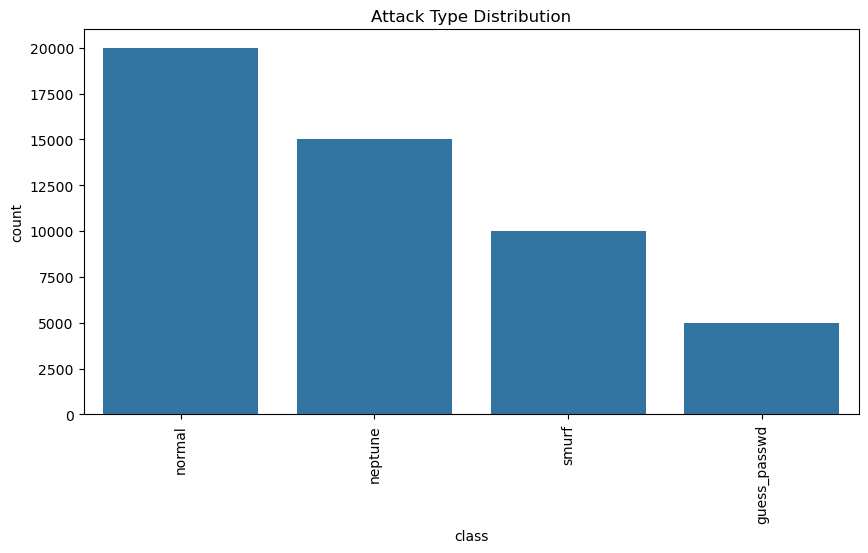

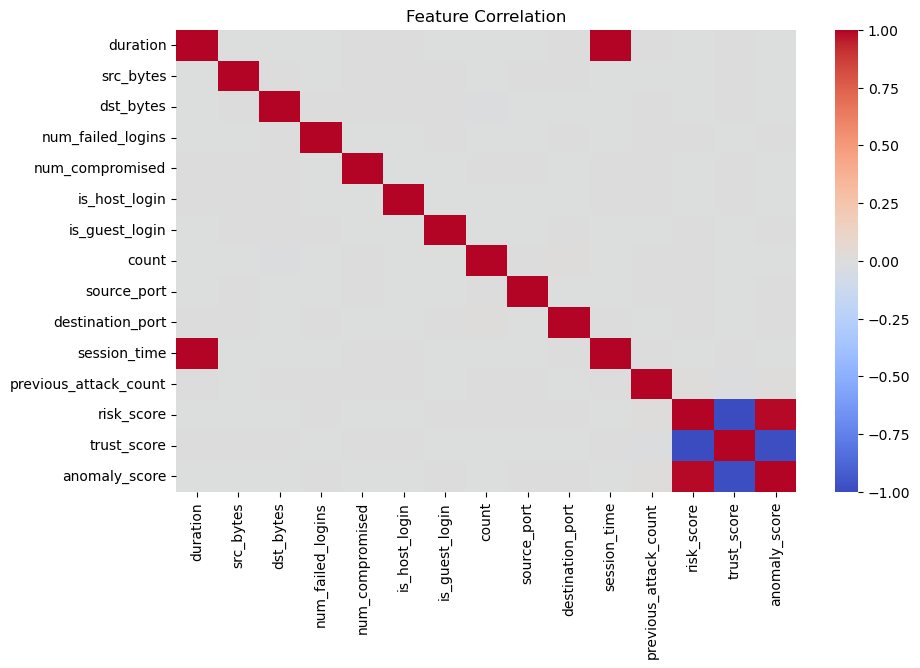

In [69]:
plt.figure(figsize=(10,5))
sns.countplot(x=train_df["class"])
plt.xticks(rotation=90)
plt.title("Attack Type Distribution")
plt.show()

# Heatmap (only numeric)
plt.figure(figsize=(10,6))
numeric_X = X.select_dtypes(include=[np.number])
sns.heatmap(numeric_X.iloc[:, :15].corr(), cmap="coolwarm")
plt.title("Feature Correlation")
plt.show()

In [70]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print("Train:", X_train.shape)
print("Test:", X_test.shape)

Train: (40000, 30)
Test: (10000, 30)


In [71]:
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

# Save scaler
with open("../model/scaler.pkl", "wb") as f:
    pickle.dump(scaler, f)

print("Scaling completed!")

Scaling completed!


In [72]:
rf = RandomForestClassifier(
    n_estimators=100,
    max_depth=6,
    min_samples_split=20,
    min_samples_leaf=10,
    max_features=0.3,
    random_state=42
)

rf.fit(X_train, y_train)
rf_acc = accuracy_score(y_test, rf.predict(X_test))

print("RF Accuracy:", rf_acc)

RF Accuracy: 0.9954


In [73]:
svm = SGDClassifier(loss="log_loss", max_iter=1000, random_state=42)

svm.fit(X_train, y_train)
svm_acc = accuracy_score(y_test, svm.predict(X_test))
print("SVM Accuracy:", svm_acc)


SVM Accuracy: 0.9932


In [74]:
mlp = MLPClassifier(hidden_layer_sizes=(50,), max_iter=150, random_state=42)

mlp.fit(X_train, y_train)
mlp_acc = accuracy_score(y_test, mlp.predict(X_test))
print("MLP Accuracy:", mlp_acc)

MLP Accuracy: 0.9936


In [75]:
ada = AdaBoostClassifier(n_estimators=50, random_state=42)

ada.fit(X_train, y_train)
ada_acc = accuracy_score(y_test, ada.predict(X_test))

print("Ada Accuracy:", ada_acc)

d:\anaconda\Lib\site-packages\sklearn\ensemble\_weight_boosting.py:527: FutureWarning: The SAMME.R algorithm (the default) is deprecated and will be removed in 1.6. Use the SAMME algorithm to circumvent this warning.
  warnings.warn(


Ada Accuracy: 0.8


In [76]:
# ================================
# SAFE ENSEMBLE WEIGHTS
# ================================

accuracies = {
    "rf": rf_acc,
    "svm": svm_acc,
    "mlp": mlp_acc,
    "ada": ada_acc
}

total = sum(accuracies.values())

weights = {model: acc / total for model, acc in accuracies.items()}

print("Model Weights:", weights)

with open("../model/model_weights.pkl", "wb") as f:
    pickle.dump(weights, f)

Model Weights: {'rf': 0.26318015969541536, 'svm': 0.2625984876526889, 'mlp': 0.26270424620591193, 'ada': 0.21151710644598384}


In [77]:
with open("../model/rf_model.pkl", "wb") as f:
    pickle.dump(rf, f)

with open("../model/svm_model.pkl", "wb") as f:
    pickle.dump(svm, f)

with open("../model/mlp_model.pkl", "wb") as f:
    pickle.dump(mlp, f)

with open("../model/ada_model.pkl", "wb") as f:
    pickle.dump(ada, f)

print("All models saved successfully!")

All models saved successfully!


In [78]:
import sys
print(sys.executable)

import sklearn
print(sklearn.__version__)

d:\anaconda\python.exe
1.5.1
